In [ ]:
import os
import elevation

# Dictionary of 10 iconic supervolcanoes / massive caldera systems
# New Standard: Exactly 1.00 degree wide and 1.00 degree tall, perfectly centered
SUPERVOLCANOES = {
    "Yellowstone_USA":          (-111.35, 43.95, -110.35, 44.95),  
    "Lake_Toba_Indonesia":      (98.20, 2.10, 99.20, 3.10),        
    "Taupo_New_Zealand":        (175.55, -39.25, 176.55, -38.25),  
    "Campi_Flegrei_Italy":      (13.75, 40.53, 14.75, 41.53),     
    "Long_Valley_USA":          (-119.30, 37.20, -118.30, 38.20), 
    "Valles_Caldera_USA":       (-106.95, 35.50, -105.95, 36.50),  
    "Aira_Caldera_Japan":       (130.30, 31.25, 131.30, 32.25),   
    "Mt_Aso_Japan":             (130.70, 32.53, 131.70, 33.53),    
    "Crater_Lake_Mazama_USA":  (-122.50, 42.55, -121.50, 43.55),  
    "La_Garita_USA":            (-107.40, 37.40, -106.40, 38.40)   
}

# Create a dedicated directory for the TIF files to keep your workspace clean
output_dir = os.path.join(os.getcwd(), 'supervolcano_dems')
os.makedirs(output_dir, exist_ok=True)

print("Starting bulk DEM download for 10 Supervolcanoes (1.0 Degree Standard)...")

for name, bounds in SUPERVOLCANOES.items():
    tif_filename = os.path.join(output_dir, f"{name}-DEM.tif")
    
    # Simple check to prevent re-downloading if you run the cell twice or download new data
    if not os.path.exists(tif_filename):
        print(f" -> Downloading {name.replace('_', ' ')}...")
        try:
            elevation.clip(bounds=bounds, output=tif_filename, max_download_tiles=25)
            elevation.clean()
        except Exception as e:
            print(f"Failed to download {name}: {e}")
    else:
        print(f" -> {name.replace('_', ' ')} DEM already exists. Skipping.")

print("\n All 1.0-degree supervolcano DEM files are ready in the 'supervolcano_dems' folder!")

# In the next cell, each super volcano tile is plot with absolute elevation data

Processing true absolute elevations with pure green baseline...
Shared Terrestrial Scale Range: 0 ft to 14009 ft
Saving high-res absolute collage to Global_SuperVolcano_Profiles.png...


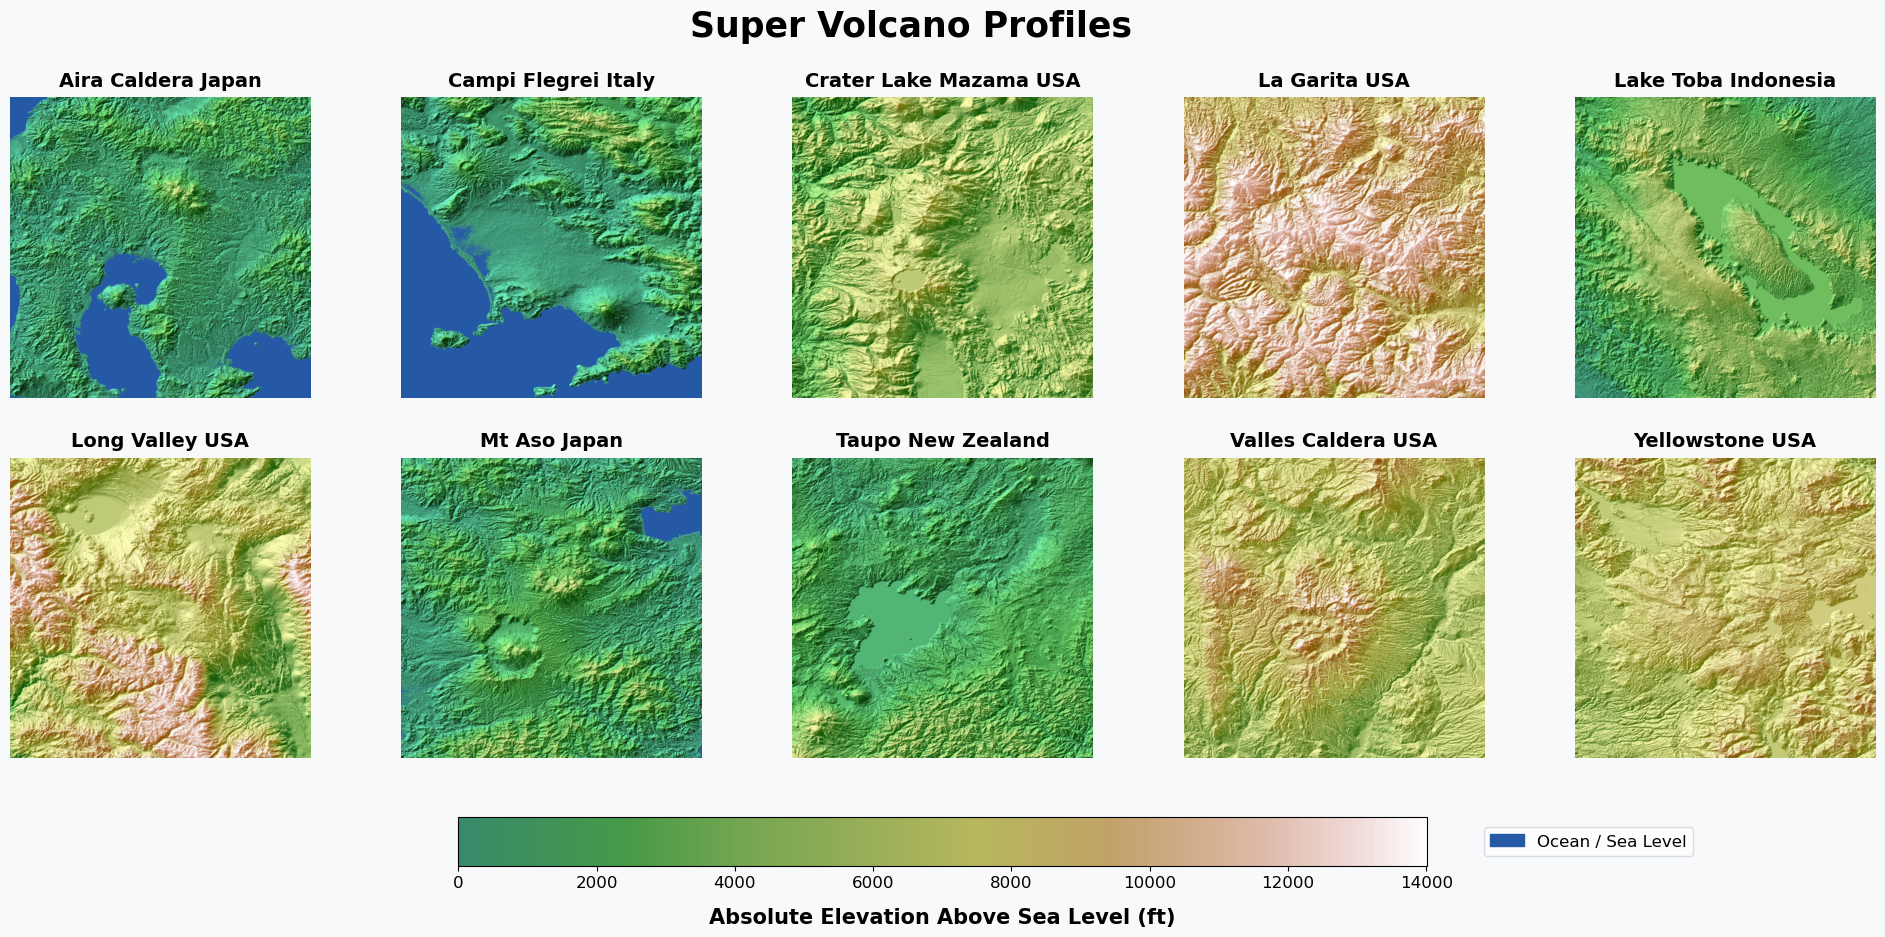

In [1]:
import os
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.colors import LightSource
from rasterio.plot import plotting_extent

# --- CONFIGURATION ---
DOWNSAMPLE_FACTOR = 1  # use 1 since these tif files are tiny
DATA_DIR = os.path.join(os.getcwd(), 'supervolcano_dems')

# List downloaded DEM files
tif_files = sorted([f for f in os.listdir(DATA_DIR) if f.endswith('.tif')])

volcano_data = []
global_max = -np.inf

print("Processing true absolute elevations with pure green baseline...")

# 1. LOAD AND TRACK TRUE ABSOLUTE MAX LAND ELEVATION
for filename in tif_files:
    v_name = filename.replace('-DEM.tif', '').replace('_', ' ')
    filepath = os.path.join(DATA_DIR, filename)
    
    with rasterio.open(filepath) as src:
        elev = src.read(1).astype('float32')
        elev[elev <= (src.nodata if src.nodata is not None else -9999)] = np.nan
        
        # Convert to feet
        elev_ft = elev * 3.28084
        elev_ft = elev_ft[::DOWNSAMPLE_FACTOR, ::DOWNSAMPLE_FACTOR]
        extent = plotting_extent(src)
        
        # Clean marine voids explicitly to 0 ft
        elev_ft = np.nan_to_num(elev_ft, nan=0.0)
        
        if len(elev_ft) > 0:
            global_max = max(global_max, np.max(elev_ft))
            
        volcano_data.append({
            'name': v_name,
            'elevation_data': elev_ft,
            'extent': extent
        })

print(f"Shared Terrestrial Scale Range: 0 ft to {global_max:.0f} ft")

# 2. FIXED COLORMAP SETUP (Slicing strictly from pure green onward)
# starting at 0.35 purges the transitional cyan/blue hues and starts at GREEN
land_colors = plt.get_cmap('gist_earth')(np.linspace(0.35, 1.0, 256))
pure_green_land_map = mcolors.LinearSegmentedColormap.from_list('pure_green_land', land_colors)

# Set up a clean solid blue color vector for the ocean mask
ocean_blue = np.array([0.15, 0.35, 0.65, 1.0])  

# Continuous absolute normalization for the land colorbar (Strictly 0 to Peak)
norm = plt.Normalize(vmin=0, vmax=global_max)

# 3. LIGHTING SETUP
ls = LightSource(azdeg=315, altdeg=20)

# 4. COLLAGE PLOTTING (2 rows, 5 columns)
fig, axes = plt.subplots(2, 5, figsize=(25, 11), gridspec_kw={'wspace': 0.05, 'hspace': 0.2})
fig.patch.set_facecolor('#f8f9fa')
axes = axes.flatten()

for i, v_dict in enumerate(volcano_data):
    ax = axes[i]
    
    # Generate standard shaded relief matrix using our pure-green map
    rgb_shaded = ls.shade(v_dict['elevation_data'], 
                          cmap=pure_green_land_map, 
                          norm=norm,
                          blend_mode='overlay', 
                          vert_exag=1)
    
    # Create a mask tracking pixels at or below sea level
    sea_level_mask = (v_dict['elevation_data'] <= 2.0)
    
    # Overwrite sea level pixels with unified solid ocean blue color
    rgb_shaded[sea_level_mask] = ocean_blue
        
    ax.imshow(rgb_shaded, extent=v_dict['extent'], origin='upper', interpolation='bilinear', aspect='equal')
    ax.set_title(v_dict['name'], fontsize=14, fontweight='bold', pad=8)
    ax.axis('off')

for j in range(len(volcano_data), len(axes)):
    axes[j].axis('off')

# 5. TERRESTRIAL-ONLY COLORBAR (Starts exactly at pure green for 0 ft)
sm = plt.cm.ScalarMappable(cmap=pure_green_land_map, norm=norm)
sm._A = []
cb = fig.colorbar(sm, ax=axes.tolist(), shrink=0.5, pad=0.07, location='bottom')
cb.set_label('Absolute Elevation Above Sea Level (ft)', fontsize=15, labelpad=12, fontweight='semibold')
cb.ax.tick_params(labelsize=12)

# 6. EXPLICIT OCEAN INDICATOR KEY
ocean_patch = mpatches.Patch(color=ocean_blue, label='Ocean / Sea Level')
cb.ax.legend(handles=[ocean_patch], loc='center left', bbox_to_anchor=(1.05, 0.5),
             frameon=True, facecolor='#ffffff', edgecolor='#d1d5db', fontsize=12)

plt.suptitle("Super Volcano Profiles", fontsize=25, fontweight='bold', y=0.96)

# Save output
output_filename = "Global_SuperVolcano_Profiles.png"
print(f"Saving high-res absolute collage to {output_filename}...")
# plt.savefig(output_filename, dpi=300, bbox_inches='tight', pad_inches=0.4)
# plt.savefig(output_filename, dpi=300, bbox_inches='tight', pad_inches=0.4,transparent=True)
plt.show()